In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [3]:
import matplotlib.pyplot as plt
import pathlib
import pandas as pd

seed_ = 42

dim = 16
directory = pathlib.Path("../events/MG3")

df_3b = pd.read_hdf(directory / "dataframes" / "threeTag_picoAOD.h5")
df_bg4b = pd.read_hdf(directory / "dataframes" / "fourTag_10x_picoAOD.h5")
df_hh4b = pd.read_hdf(directory / "dataframes" / "HH4b_picoAOD.h5")
df_hh4b_400 = pd.read_hdf(directory / "dataframes" / "HH4b_400.h5")
df_hh4b_800 = pd.read_hdf(directory / "dataframes" / "HH4b_800.h5")
df_zh4b = pd.read_hdf(directory / "dataframes" / "ZH4b_picoAOD.h5")
df_zz4b = pd.read_hdf(directory / "dataframes" / "ZZ4b_picoAOD.h5")
df_zh4b_0 = pd.read_hdf(directory / "dataframes" / "picoAOD_ZH4b.chunk0.h5")
df_zh4b_1 = pd.read_hdf(directory / "dataframes" / "picoAOD_ZH4b.chunk1.h5")
df_zz4b_0 = pd.read_hdf(directory / "dataframes" / "picoAOD_ZZ4b.chunk0.h5")
df_zz4b_1 = pd.read_hdf(directory / "dataframes" / "picoAOD_ZZ4b.chunk1.h5")
df_zh4b_cleaned = pd.read_hdf(directory / "dataframes" / "ZH4b_picoAOD_cleaned.h5")
df_zz4b_cleaned = pd.read_hdf(directory / "dataframes" / "ZZ4b_picoAOD_cleaned.h5")

df_3b["signal"] = False
df_bg4b["signal"] = False
df_hh4b["signal"] = True
df_hh4b_400["signal"] = True
df_hh4b_800["signal"] = True
df_zh4b["signal"] = True
df_zz4b["signal"] = True
df_zh4b_0["signal"] = True
df_zh4b_1["signal"] = True
df_zz4b_0["signal"] = True
df_zz4b_1["signal"] = True
df_zh4b_cleaned["signal"] = True
df_zz4b_cleaned["signal"] = True

print("3b-jet events: ", len(df_3b))
print("4b-jet events: ", len(df_bg4b))
print("HH4b-jet events: ", len(df_hh4b))
print("HH4b_400-jet events: ", len(df_hh4b_400))
print("HH4b_800-jet events: ", len(df_hh4b_800))
print("ZH4b-jet events: ", len(df_zh4b))
print("ZZ4b-jet events: ", len(df_zz4b))

# shuffle the data
df_3b = df_3b.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_bg4b = df_bg4b.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_hh4b = df_hh4b.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_hh4b_400 = df_hh4b_400.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_hh4b_800 = df_hh4b_800.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_zh4b = df_zh4b.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_zz4b = df_zz4b.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_zh4b_cleaned = df_zh4b_cleaned.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_zz4b_cleaned = df_zz4b_cleaned.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_zh4b_0 = df_zh4b_0.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_zh4b_1 = df_zh4b_1.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_zz4b_0 = df_zz4b_0.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_zz4b_1 = df_zz4b_1.sample(frac=1, random_state=seed_).reset_index(drop=True)

3b-jet events:  2013103
4b-jet events:  2202261
HH4b-jet events:  30856
HH4b_400-jet events:  44196
HH4b_800-jet events:  97038
ZH4b-jet events:  200000
ZZ4b-jet events:  200000


In [4]:
# import numpy as np
# from itertools import combinations

# pt = df_zh4b[["Jet0_pt", "Jet1_pt", "Jet2_pt", "Jet3_pt"]].values
# idx = np.zeros(len(pt), dtype=bool)
# for i, j in combinations(range(pt.shape[1]), 2):
#     idx = idx | (pt[:, i] == pt[:, j])

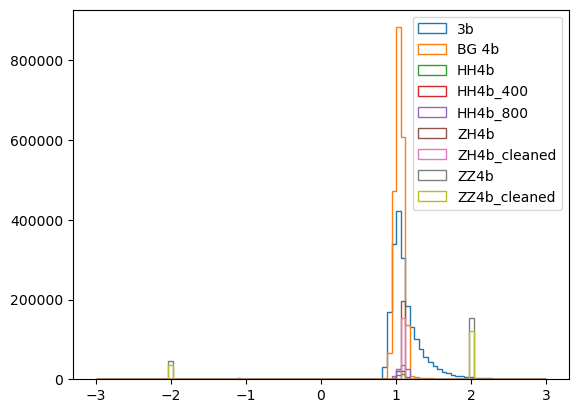

In [4]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.linspace(-3, 3, 100)
for label, df in [
    ("3b", df_3b),
    ("BG 4b", df_bg4b),
    ("HH4b", df_hh4b),
    ("HH4b_400", df_hh4b_400),
    ("HH4b_800", df_hh4b_800),
    ("ZH4b", df_zh4b),
    ("ZH4b_cleaned", df_zh4b_cleaned),
    ("ZZ4b", df_zz4b),
    ("ZZ4b_cleaned", df_zz4b_cleaned),
]:
    plt.hist(df["weight"], bins=bins, histtype="step", label=label)
plt.legend()
plt.show()

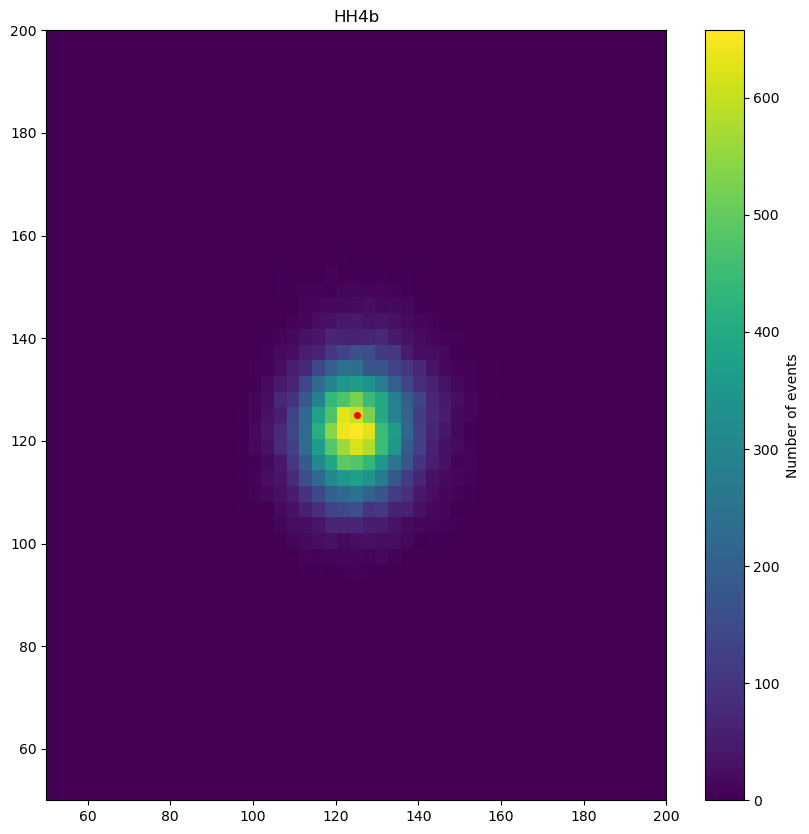

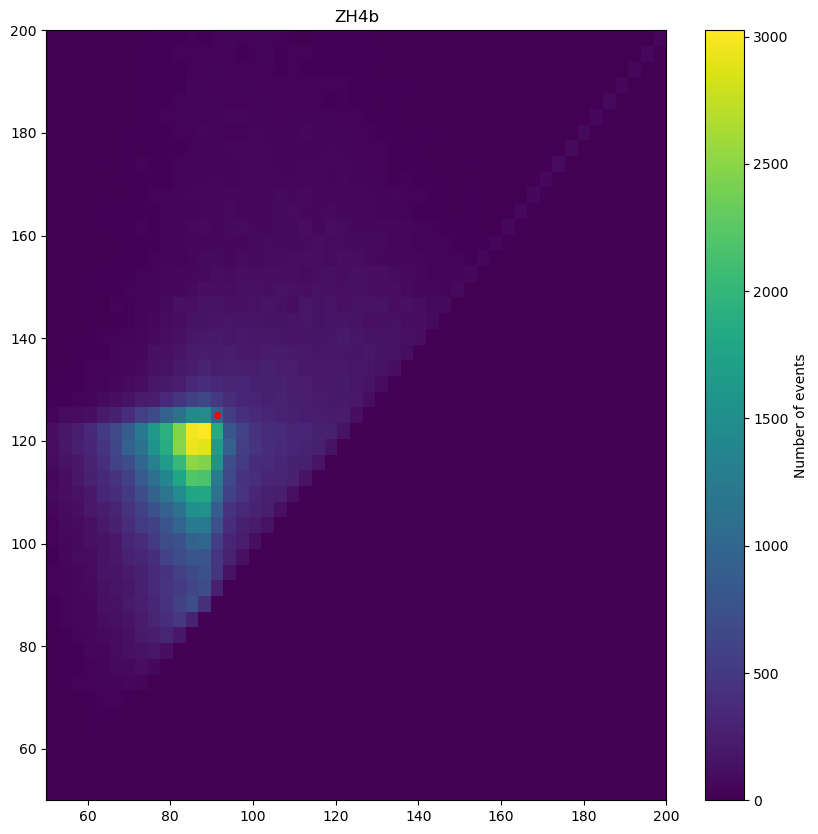

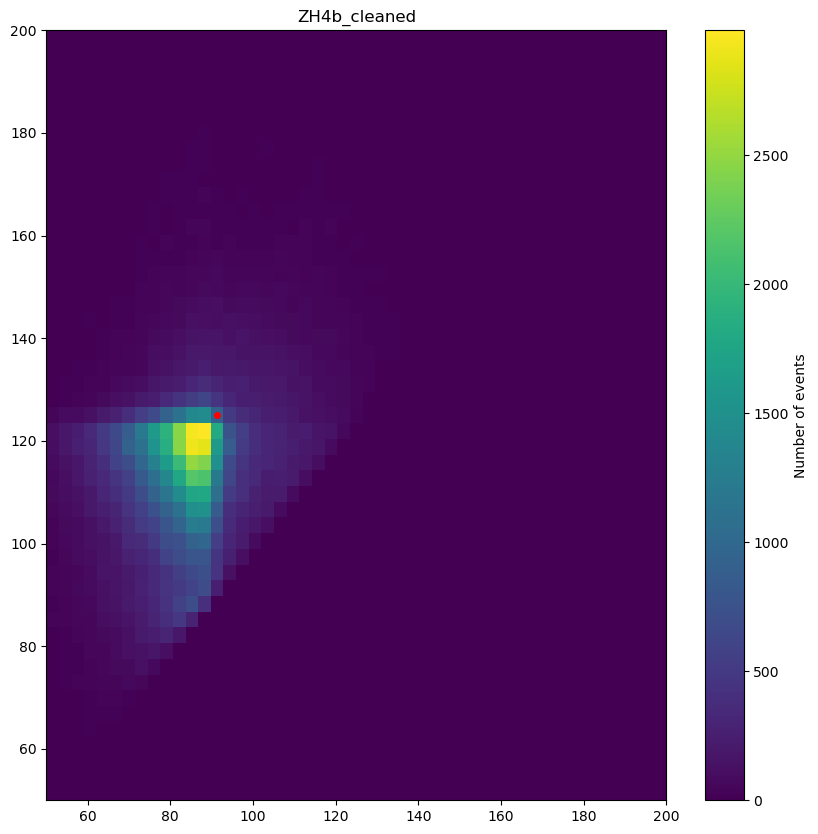

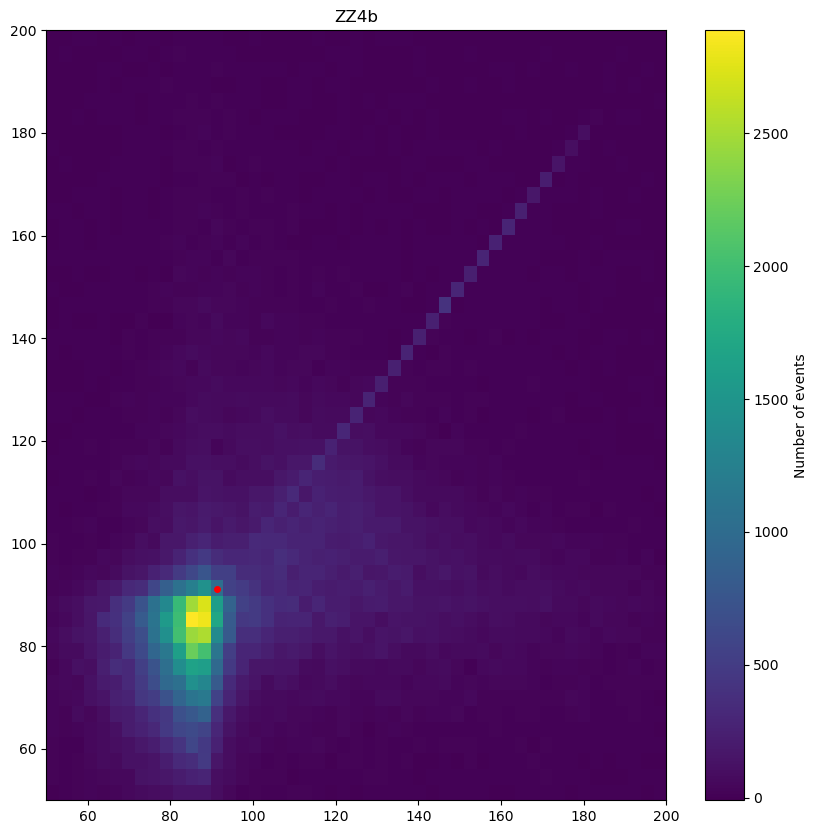

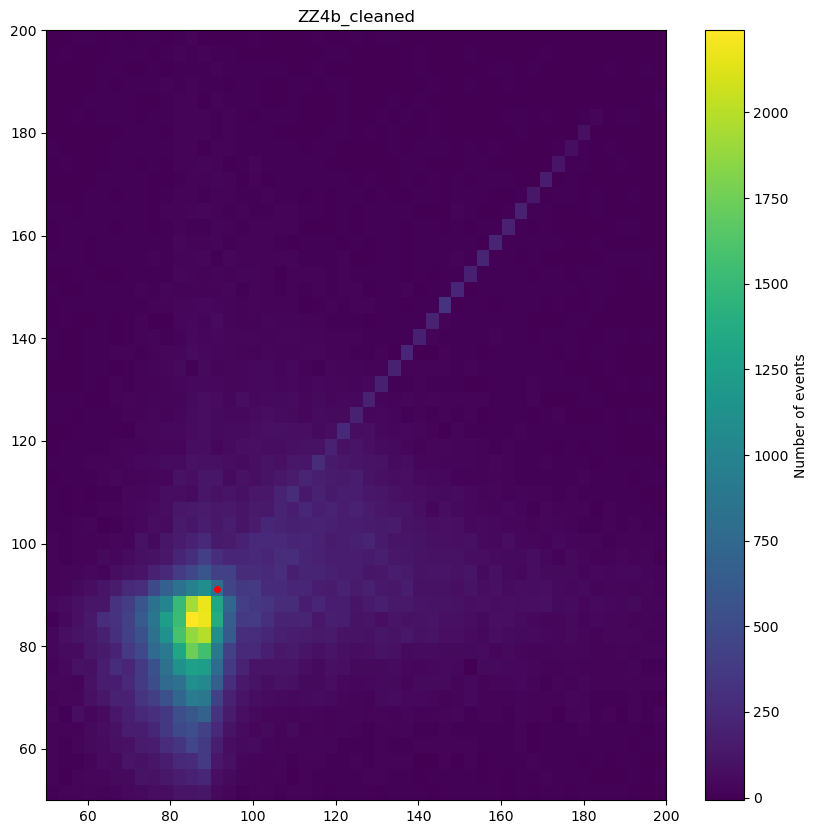

In [6]:
import matplotlib.pyplot as plt
import numpy as np

mZ = 91.1880
mH = 125.11

for label, df in [
           ("HH4b", df_hh4b), 
           ("ZH4b", df_zh4b), ("ZH4b_cleaned", df_zh4b_cleaned), 
           ("ZZ4b", df_zz4b), ("ZZ4b_cleaned", df_zz4b_cleaned),
           ]:
    fig, ax = plt.subplots(figsize=(10, 10))
    
    if label == "HH4b":
        M1, M2 = mH, mH
    elif label == "ZH4b":
        M1, M2 = mZ, mH
    elif label == "ZZ4b":
        M1, M2 = mZ, mZ
    
    m_err = np.stack(
        [(df["m01"] - M1)**2 + (df["m23"] - M2)**2,
        (df["m02"] - M1)**2 + (df["m13"] - M2)**2,
        (df["m03"] - M1)**2 + (df["m12"] - M2)**2,
        (df["m23"] - M1)**2 + (df["m01"] - M2)**2,
        (df["m13"] - M1)**2 + (df["m02"] - M2)**2,
        (df["m12"] - M1)**2 + (df["m03"] - M2)**2,
        ], axis=1)
    m_err_argmin = np.argmin(m_err, axis=1)
    m1 = np.zeros_like(df["m01"])
    m2 = np.zeros_like(df["m01"])
    
    m1[m_err_argmin == 0] = df["m01"][m_err_argmin == 0]
    m2[m_err_argmin == 0] = df["m23"][m_err_argmin == 0]
    
    m1[m_err_argmin == 1] = df["m02"][m_err_argmin == 1]
    m2[m_err_argmin == 1] = df["m13"][m_err_argmin == 1]
    
    m1[m_err_argmin == 2] = df["m03"][m_err_argmin == 2]
    m2[m_err_argmin == 2] = df["m12"][m_err_argmin == 2]
    
    m1[m_err_argmin == 3] = df["m23"][m_err_argmin == 3]
    m2[m_err_argmin == 3] = df["m01"][m_err_argmin == 3]
    
    m1[m_err_argmin == 4] = df["m13"][m_err_argmin == 4] 
    m2[m_err_argmin == 4] = df["m02"][m_err_argmin == 4]
    
    m1[m_err_argmin == 5] = df["m12"][m_err_argmin == 5]
    m2[m_err_argmin == 5] = df["m03"][m_err_argmin == 5]
    
    x_bins = np.linspace(50, 200, 50)
    y_bins = np.linspace(50, 200, 50)
    _, _, _, im = ax.hist2d(m1, m2, bins=(x_bins, y_bins), cmap="viridis", weights=df["weight"])
    cbar = plt.colorbar(im)
    cbar.set_label("Number of events")
    ax.plot(M1, M2, "o", markersize=4, color="red")
    ax.set_xlim(50, 200)
    ax.set_ylim(50, 200)
    ax.set_title(label)

    plt.show()
    plt.close()

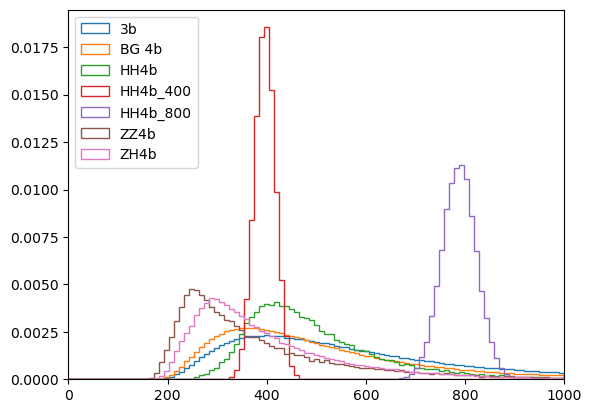

In [ ]:
from constants import FEATURES
from ancillary_features import get_m4j
import torch

bins = np.linspace(0, 1000, 100)
for label, df in [
    ("3b", df_3b),
    ("BG 4b", df_bg4b),
    ("HH4b", df_hh4b), 
    ("HH4b_400", df_hh4b_400), 
    ("HH4b_800", df_hh4b_800), 
    ("ZZ4b", df_zz4b), 
    ("ZH4b", df_zh4b),
]:
    m4j = get_m4j(torch.tensor(df[FEATURES].values))
    plt.hist(m4j, bins=bins, histtype="step", label=label, weights=df["weight"], 
             density=True)
plt.xlim(0, 1000)
plt.legend()
plt.show()
plt.close()

In [2]:
# import ROOT
# import pathlib

# directory = pathlib.Path("../events/MG3")
# f = ROOT.TFile(str(directory / "TTree" / "picoAOD_ZH4b.chunk0.root"))
# f.ls()
# t = f.Get("Events")
# t.Print()

# print(t.GetEntries())
# t.GetEntry(5000)
# print(t.genWeight[3])

In [2]:
from copy import deepcopy
import logging
import torch
import pandas as pd
import numpy as np
import pytorch_lightning as pl
import click
import yaml


from fvt_classifier import FvTClassifier
from dataset import MotherSamples
from training_info import TrainingInfo
from utils import require_keys

n_3b = 100_0000
ratio_4b = 0.5
signal_ratio = 0.005
signal_filename = "HH4b_resonant_picoAOD_v1.h5"
# seed = 0

ms_hparams = {
        "n_3b": n_3b,
        "ratio_4b": ratio_4b,
        "signal_ratio": signal_ratio,
        "signal_filename": signal_filename,
        # "seed": seed,
    }
hashes = MotherSamples.find(ms_hparams, from_metadata=False)

754it [00:03, 193.19it/s]


In [3]:
len(hashes)

254

In [3]:
# import ROOT
# import pathlib


# directory = pathlib.Path("../../events/MG3")
# f = ROOT.TFile(str(directory / "TTree" / "fourTag_10x_picoAOD.root"))
# # f.ls()
# t = f.Get("Events")
# t.Print()

# data = {
#     "Jet0_pt": [],
#     "Jet1_pt": [],
#     "Jet2_pt": [],
#     "Jet3_pt": [],
#     "Jet0_eta": [],
#     "Jet1_eta": [],
#     "Jet2_eta": [],
#     "Jet3_eta": [],
#     "Jet0_phi": [],
#     "Jet1_phi": [],
#     "Jet2_phi": [],
#     "Jet3_phi": [],
#     "Jet0_m": [],
#     "Jet1_m": [],
#     "Jet2_m": [],
#     "Jet3_m": [],
#     "m01": [],
#     "m23": [],
#     "m02": [],
#     "m13": [],
#     "m03": [],
#     "m12": [],
# }



Welcome to JupyROOT 6.30/04


Error in <TFile::TFile>: file /home/export/soheuny/SRFinder/soheun/../../events/MG3/TTree/fourTag_10x_picoAOD.root does not exist


OSError: Failed to open file ../../events/MG3/TTree/fourTag_10x_picoAOD.root

In [2]:
import pandas as pd
import numpy as np

data = {
    "Jet0_pt": [],
    "Jet1_pt": [],
    "Jet2_pt": [],
    "Jet3_pt": [],
    "Jet0_eta": [],
    "Jet1_eta": [],
    "Jet2_eta": [],
    "Jet3_eta": [],
    "Jet0_phi": [],
    "Jet1_phi": [],
    "Jet2_phi": [],
    "Jet3_phi": [],
    "Jet0_m": [],
    "Jet1_m": [],
    "Jet2_m": [],
    "Jet3_m": [],
    "m01": [],
    "m23": [],
    "m02": [],
    "m13": [],
    "m03": [],
    "m12": [],
}
for idx in range(10000):
    t.GetEntry(idx)
    data["Jet0_pt"].append(t.Jet_pt[0])
    data["Jet1_pt"].append(t.Jet_pt[1])
    data["Jet2_pt"].append(t.Jet_pt[2])
    data["Jet3_pt"].append(t.Jet_pt[3])
    data["Jet0_eta"].append(t.Jet_eta[0])
    data["Jet1_eta"].append(t.Jet_eta[1])
    data["Jet2_eta"].append(t.Jet_eta[2])
    data["Jet3_eta"].append(t.Jet_eta[3])
    data["Jet0_phi"].append(t.Jet_phi[0])
    data["Jet1_phi"].append(t.Jet_phi[1])
    data["Jet2_phi"].append(t.Jet_phi[2])
    data["Jet3_phi"].append(t.Jet_phi[3])
    data["Jet0_m"].append(t.Jet_mass[0])
    data["Jet1_m"].append(t.Jet_mass[1])
    data["Jet2_m"].append(t.Jet_mass[2])
    data["Jet3_m"].append(t.Jet_mass[3])

    jets = [
                ROOT.TLorentzVector(),
                ROOT.TLorentzVector(),
                ROOT.TLorentzVector(),
                ROOT.TLorentzVector(),
            ]
    for i in range(4):
        jets[i].SetPtEtaPhiM(
            t.Jet_pt[i], t.Jet_eta[i], t.Jet_phi[i], t.Jet_mass[i]
        )

    data["m01"].append((jets[0] + jets[1]).M())
    data["m23"].append((jets[2] + jets[3]).M())
    data["m02"].append((jets[0] + jets[2]).M())
    data["m13"].append((jets[1] + jets[3]).M())
    data["m03"].append((jets[0] + jets[3]).M())
    data["m12"].append((jets[1] + jets[2]).M())
    
df = pd.DataFrame(data)

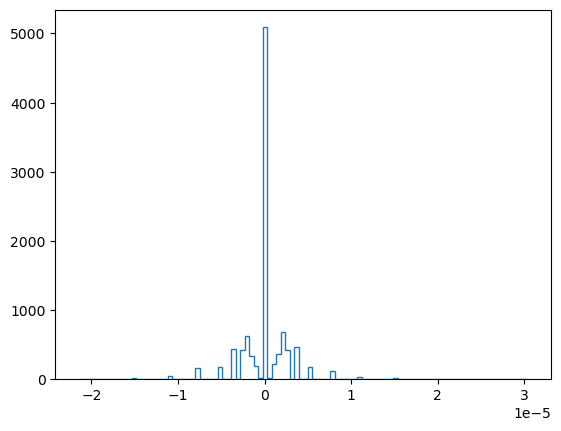

In [4]:
import matplotlib.pyplot as plt
plt.hist(df["Jet0_m"], bins=100, histtype="step")
plt.show()

In [5]:
import torch
import pathlib
import numpy as np
import pandas as pd

seed_ = 42

dim = 16
directory = pathlib.Path("../events/MG3")

df_3b = pd.read_hdf(directory / "dataframes" / "bbbj.h5")
df_bg4b = pd.read_hdf(directory / "dataframes" / "bbbb_large.h5")
df_hh4b = pd.read_hdf(directory / "dataframes" / "HH4b.h5")

df_3b["signal"] = False
df_bg4b["signal"] = False
df_hh4b["signal"] = True

print("3b-jet events: ", len(df_3b))
print("4b-jet events: ", len(df_bg4b))
print("HH4b-jet events: ", len(df_hh4b))

# shuffle the data
df_3b = df_3b.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_bg4b = df_bg4b.sample(frac=1, random_state=seed_).reset_index(drop=True)
df_hh4b = df_hh4b.sample(frac=1, random_state=seed_).reset_index(drop=True)

3b-jet events:  275508
4b-jet events:  382108
HH4b-jet events:  28656


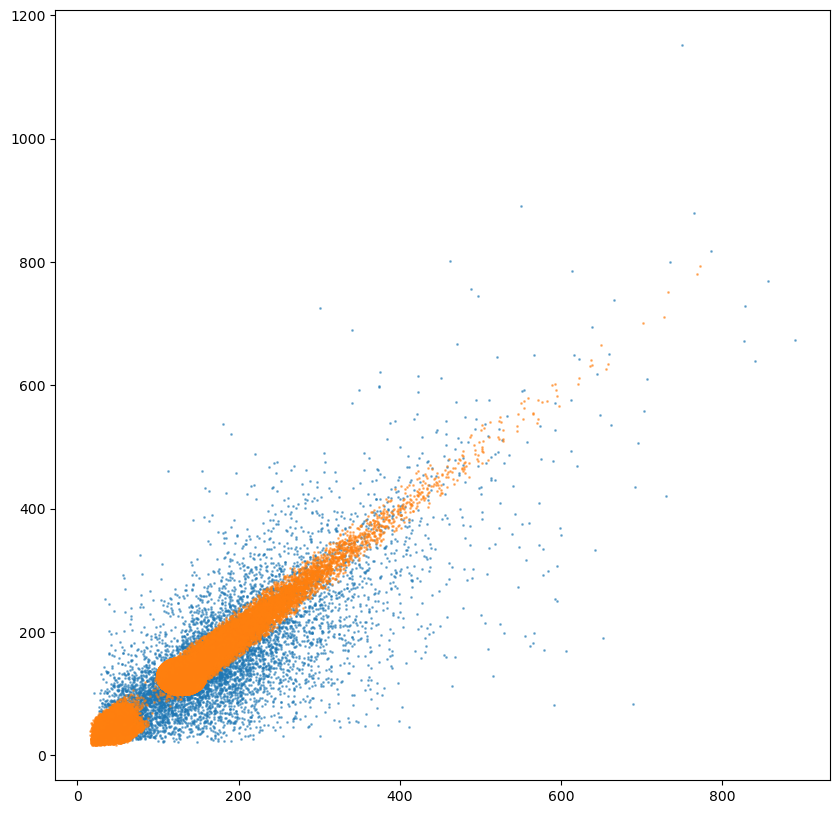

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

m_diff = np.stack(
    [df["m01"] - df["m23"],
     df["m02"] - df["m13"], 
     df["m03"] - df["m12"],
    ], axis=1)
m_diff = np.abs(m_diff)
m_diff_argmin = np.argmin(m_diff, axis=1)
m1 = np.where(m_diff_argmin == 0, df["m01"],
                np.where(m_diff_argmin == 1, df["m02"], df["m03"]))
m2 = np.where(m_diff_argmin == 0, df["m23"],
                np.where(m_diff_argmin == 1, df["m13"], df["m12"]))

ax.plot(m1, m2, "o", alpha=0.5, markersize=1)


m_diff = np.stack(
    [df_bg4b["m01"] - df_bg4b["m23"],
     df_bg4b["m02"] - df_bg4b["m13"], 
     df_bg4b["m03"] - df_bg4b["m12"],
    ], axis=1)
m_diff = np.abs(m_diff)
m_diff_argmin = np.argmin(m_diff, axis=1)
m1 = np.where(m_diff_argmin == 0, df_bg4b["m01"],
                np.where(m_diff_argmin == 1, df_bg4b["m02"], df_bg4b["m03"]))
m2 = np.where(m_diff_argmin == 0, df_bg4b["m23"],
                np.where(m_diff_argmin == 1, df_bg4b["m13"], df_bg4b["m12"]))
ax.plot(m1, m2, "o", alpha=0.5, markersize=1)

plt.show()
plt.close()


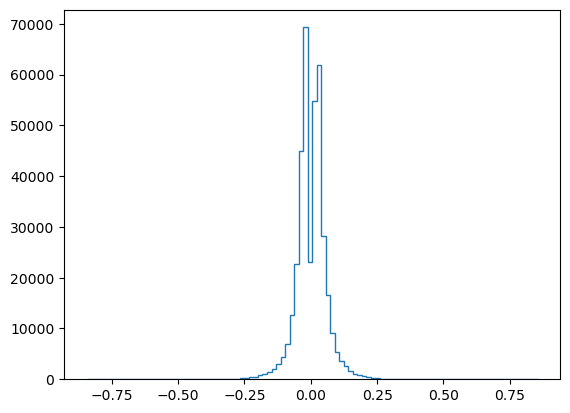

In [7]:
plt.hist(df_bg4b["canJet0_m"], bins=100, histtype="step")
plt.show()
plt.close()

In [25]:
df_zz4b_0.columns

Index(['Jet0_pt', 'Jet1_pt', 'Jet2_pt', 'Jet3_pt', 'Jet0_eta', 'Jet1_eta',
       'Jet2_eta', 'Jet3_eta', 'Jet0_phi', 'Jet1_phi', 'Jet2_phi', 'Jet3_phi',
       'Jet0_m', 'Jet1_m', 'Jet2_m', 'Jet3_m', 'weight', 'fourTag', 'm01',
       'm23', 'm02', 'm13', 'm03', 'm12', 'pt01', 'pt23', 'pt02', 'pt13',
       'pt03', 'pt12', 'dR01', 'dR23', 'dR02', 'dR13', 'dR03', 'dR12',
       'dR0123', 'dR0213', 'dR0312', 's4j', 'm4j'],
      dtype='object')

In [35]:
# import pandas as pd

# path_zz4b_0 = directory / "dataframes" / "picoAOD_ZZ4b.chunk0.h5"
# path_zz4b_1 = directory / "dataframes" / "picoAOD_ZZ4b.chunk1.h5"
# path_zh4b_0 = directory / "dataframes" / "picoAOD_ZH4b.chunk0.h5"
# path_zh4b_1 = directory / "dataframes" / "picoAOD_ZH4b.chunk1.h5"

# df_zz4b_0 = pd.read_hdf(path_zz4b_0)
# df_zz4b_1 = pd.read_hdf(path_zz4b_1)
# df_zh4b_0 = pd.read_hdf(path_zh4b_0)
# df_zh4b_1 = pd.read_hdf(path_zh4b_1)

In [34]:
# import numpy as np

# for path, df in zip(
#     [path_zz4b_0, path_zz4b_1, path_zh4b_0, path_zh4b_1],
#     [df_zz4b_0, df_zz4b_1, df_zh4b_0, df_zh4b_1],
# ):
#     df_pt_argsort = np.argsort(df[["Jet0_pt", "Jet1_pt", "Jet2_pt", "Jet3_pt"]].values, axis=1, kind="mergesort")
#     df_pt_argsort = df_pt_argsort[:, ::-1]

#     new_df = []
#     for row, argsort in zip(df.itertuples(), df_pt_argsort):
#         new_row = {}
#         for key in ["pt", "eta", "phi", "m"]:
#             for i in range(4):
#                 new_row[f"Jet{i}_{key}"] = getattr(row, f"Jet{argsort[i]}_{key}")
#         new_row["weight"] = row.weight
#         new_row["fourTag"] = row.fourTag
#         for key in ["m", "pt", "dR"]:
#             for i in range(4):
#                 for j in range(i+1, 4):
#                     sorted_idx = np.sort(np.array([argsort[i], argsort[j]]))
#                     new_row[f"{key}{i}{j}"] = getattr(row, f"{key}{sorted_idx[0]}{sorted_idx[1]}")
        
#         tmp = np.sort(argsort[[0, 1]])
#         other_idx = np.sort(np.setdiff1d(np.arange(4), tmp))
#         if 0 in tmp:
#             new_row["dR0123"] = getattr(row, f"dR{tmp[0]}{tmp[1]}{other_idx[0]}{other_idx[1]}")
#         else:
#             new_row["dR0123"] = getattr(row, f"dR{other_idx[0]}{other_idx[1]}{tmp[0]}{tmp[1]}")
            
#         tmp = np.sort(argsort[[0, 2]])
#         other_idx = np.sort(np.setdiff1d(np.arange(4), tmp))
#         if 0 in tmp:
#             new_row["dR0213"] = getattr(row, f"dR{tmp[0]}{tmp[1]}{other_idx[0]}{other_idx[1]}")
#         else:
#             new_row["dR0213"] = getattr(row, f"dR{other_idx[0]}{other_idx[1]}{tmp[0]}{tmp[1]}")
        
#         tmp = np.sort(argsort[[0, 3]])
#         other_idx = np.sort(np.setdiff1d(np.arange(4), tmp))
#         if 0 in tmp:
#             new_row["dR0312"] = getattr(row, f"dR{tmp[0]}{tmp[1]}{other_idx[0]}{other_idx[1]}")
#         else:
#             new_row["dR0312"] = getattr(row, f"dR{other_idx[0]}{other_idx[1]}{tmp[0]}{tmp[1]}")
        
#         new_row["s4j"] = row.s4j
#         new_row["m4j"] = row.m4j
#         new_df.append(new_row)
#     new_df = pd.DataFrame(new_df)
#     new_df.to_hdf(path, key="df")

In [ ]:
# path_zz4b_0 = directory / "dataframes" / "picoAOD_ZZ4b.chunk0.h5"
# path_zz4b_1 = directory / "dataframes" / "picoAOD_ZZ4b.chunk1.h5"
# path_zh4b_0 = directory / "dataframes" / "picoAOD_ZH4b.chunk0.h5"
# path_zh4b_1 = directory / "dataframes" / "picoAOD_ZH4b.chunk1.h5"
# path_zz4b = directory / "dataframes" / "ZZ4b_picoAOD.h5"
# path_zh4b = directory / "dataframes" / "ZH4b_picoAOD.h5"

# zz4b_0 = pd.read_hdf(path_zz4b_0, key="df")
# zz4b_1 = pd.read_hdf(path_zz4b_1, key="df")
# zh4b_0 = pd.read_hdf(path_zh4b_0, key="df")
# zh4b_1 = pd.read_hdf(path_zh4b_1, key="df")

# zz4b = pd.concat([zz4b_0, zz4b_1])
# zz4b.to_hdf(path_zz4b, key="df")
# zh4b = pd.concat([zh4b_0, zh4b_1])
# zh4b.to_hdf(path_zh4b, key="df")

3b-jet events:  2013103
4b-jet events:  2202261
HH4b-jet events:  30856
HH4b_400-jet events:  44196
HH4b_800-jet events:  97038
ZH4b-jet events:  200000
ZZ4b-jet events:  200000


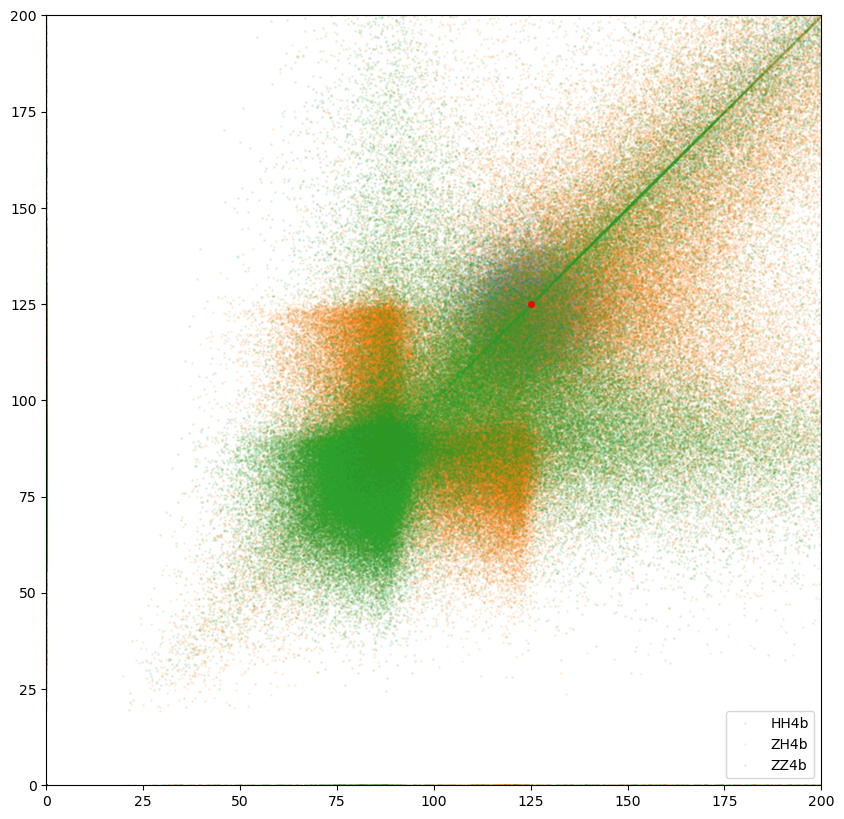

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))
for label, df in [
    # ("3b", df_3b), ("4b", df_bg4b), 
           ("HH4b", df_hh4b), 
        #    ("HH4b_400", df_hh4b_400), ("HH4b_800", df_hh4b_800), 
           ("ZH4b", df_zh4b), ("ZZ4b", df_zz4b),
        #    ("ZH4b_0", df_zh4b_0), ("ZH4b_1", df_zh4b_1), 
        #    ("ZZ4b_0", df_zz4b_0), ("ZZ4b_1", df_zz4b_1),
           ]:
    m_diff = np.stack(
        [df["m01"] - df["m23"],
        df["m02"] - df["m13"], 
        df["m03"] - df["m12"],
        ], axis=1)
    m_diff = np.abs(m_diff)
    m_diff_argmin = np.argmin(m_diff, axis=1)
    m1 = np.where(m_diff_argmin == 0, df["m01"],
                    np.where(m_diff_argmin == 1, df["m02"], df["m03"]))
    m2 = np.where(m_diff_argmin == 0, df["m23"],
                    np.where(m_diff_argmin == 1, df["m13"], df["m12"]))
    ax.plot(m1, m2, "o", alpha=0.1, markersize=1, label=label)
    

ax.plot(125, 125, "o", markersize=4, color="red")
ax.set_xlim(0, 200)
ax.set_ylim(0, 200)
ax.legend(loc="lower right")

plt.show()
plt.close()

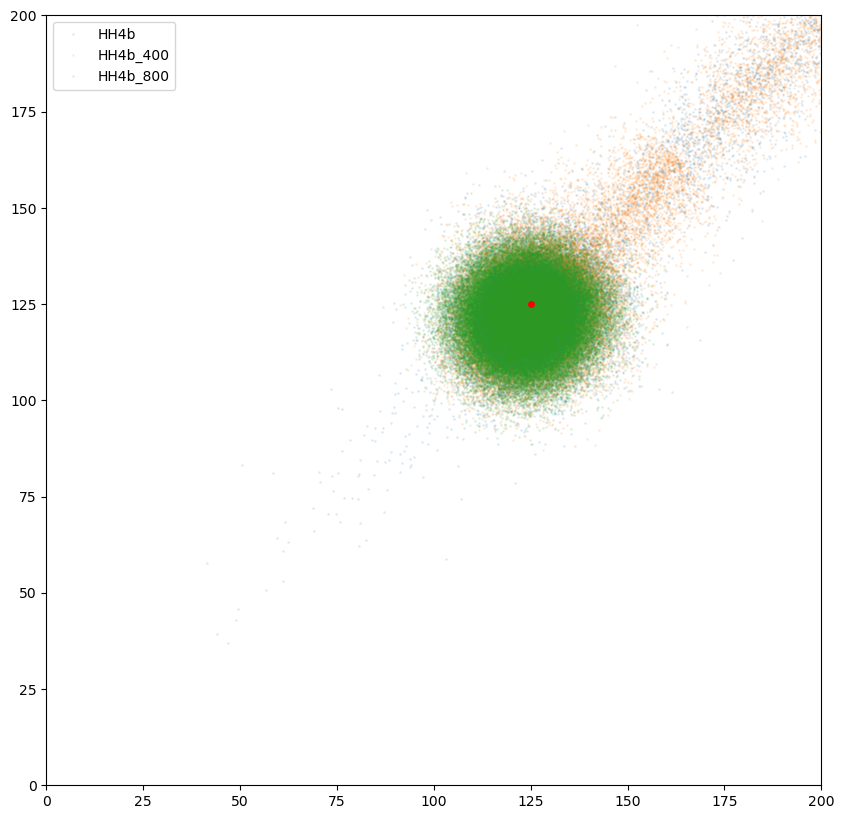

In [55]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))
for label, df in [("HH4b", df_hh4b), ("HH4b_400", df_hh4b_400), ("HH4b_800", df_hh4b_800)]:
    m_diff = np.stack(
        [df["m01"] - df["m23"],
        df["m02"] - df["m13"], 
        df["m03"] - df["m12"],
        ], axis=1)
    m_diff = np.abs(m_diff)
    m_diff_argmin = np.argmin(m_diff, axis=1)
    m1 = np.where(m_diff_argmin == 0, df["m01"],
                    np.where(m_diff_argmin == 1, df["m02"], df["m03"]))
    m2 = np.where(m_diff_argmin == 0, df["m23"],
                    np.where(m_diff_argmin == 1, df["m13"], df["m12"]))
    ax.plot(m1, m2, "o", alpha=0.1, markersize=1, label=label)

ax.plot(125, 125, "o", markersize=4, color="red")
ax.set_xlim(0, 200)
ax.set_ylim(0, 200)

ax.legend()
plt.show()
plt.close()


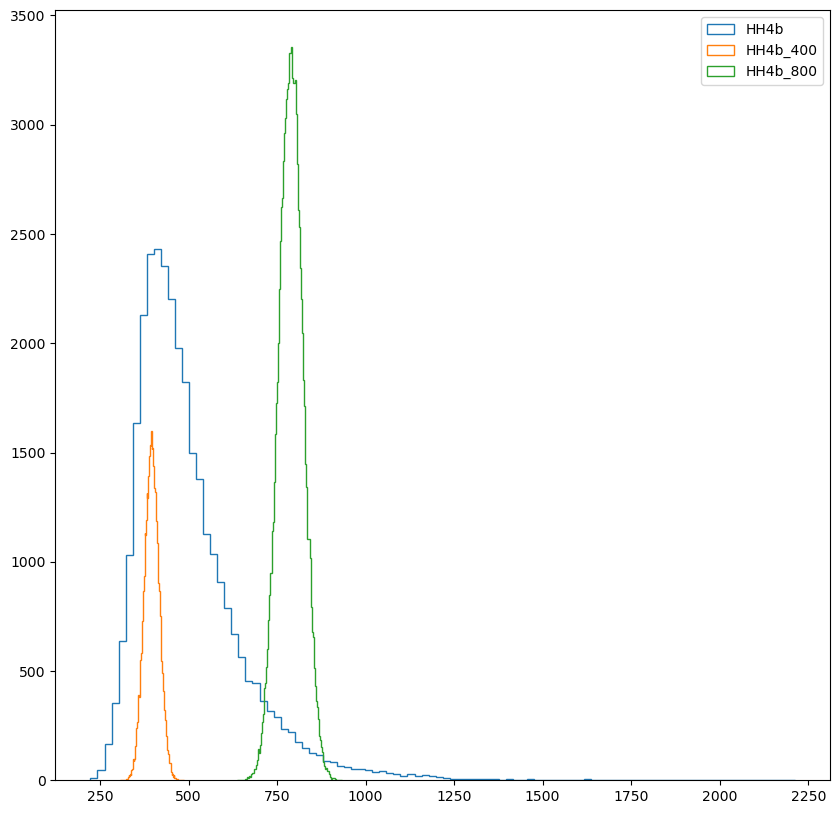

In [56]:
fig, ax = plt.subplots(figsize=(10, 10))
for label, df in [("HH4b", df_hh4b), ("HH4b_400", df_hh4b_400), ("HH4b_800", df_hh4b_800)]:
    ax.hist(df["m4j"], bins=100, histtype="step", label=label)
ax.legend()
plt.show()
plt.close()


3b in SR: 0.07266294869164668
Background $\mathrm{4b}$ in SR: 0.08501353835898652
$\mathrm{HH} \rightarrow 4b$ in SR: 0.8047705470572984


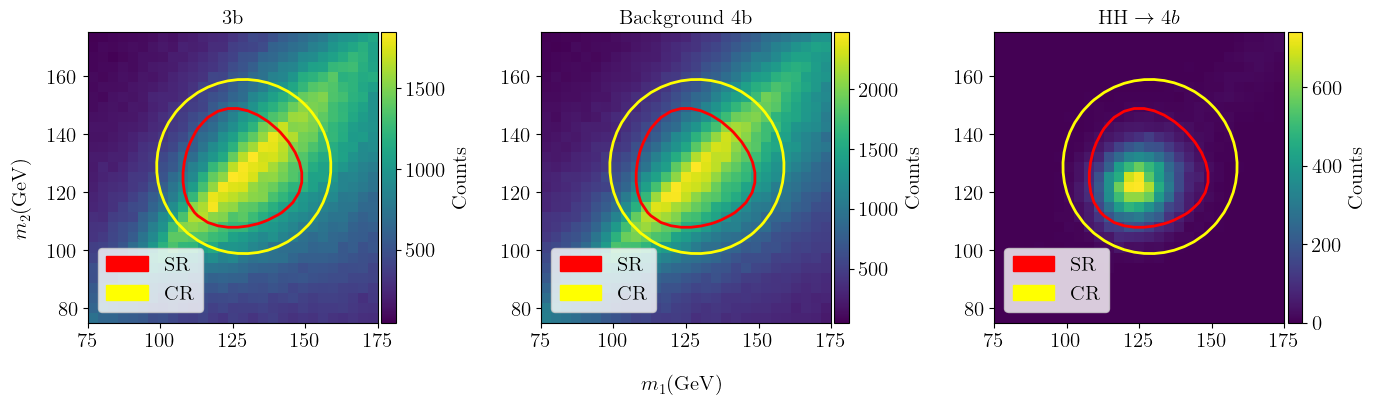

In [6]:
# density plot
from matplotlib import patches as mpatches

CR_color = "#0070c0"
SR_color = "#4ea230"


# use latex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 15

m_H = 125
sigma_C = 1
K_s = 1
K_c = 1
sigma_C = 1.03
K_s = 0.16
K_c = 30

SR_fn = lambda dm_0, dm_1: np.sqrt((1 - m_H / dm_0)**2 + (1 - m_H / dm_1)**2) 
CR_fn = lambda dm_0, dm_1: np.sqrt((dm_0 - sigma_C * m_H)**2 + (dm_1 - sigma_C * m_H)**2) 

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
fig.supxlabel("$m_1 (\mathrm{GeV})$")
fig.supylabel("$m_2 (\mathrm{GeV})$")
for ax, (name, df) in zip(axs, [("3b", df_3b), (r"Background $\mathrm{4b}$", df_bg4b), (r"$\mathrm{HH} \rightarrow 4b$", df_hh4b)]):
    m_diff = np.stack(
        [df["m01"] - df["m23"],
        df["m02"] - df["m13"], 
        df["m03"] - df["m12"],
        ], axis=1)
    m_diff = np.abs(m_diff)
    m_diff_argmin = np.argmin(m_diff, axis=1)
    m1 = np.where(m_diff_argmin == 0, df["m01"],
                    np.where(m_diff_argmin == 1, df["m02"], df["m03"]))
    m2 = np.where(m_diff_argmin == 0, df["m23"],
                    np.where(m_diff_argmin == 1, df["m13"], df["m12"]))
    
    print(f"{name} in SR: {np.mean(SR_fn(m1, m2) < K_s)}")
    
    # heatmap
    m_min = 75
    m_max = 175
    xedges = np.linspace(m_min, m_max, 30)
    yedges = np.linspace(m_min, m_max, 30)
    H, xedges, yedges = np.histogram2d(m1, m2, bins=(xedges, yedges))
    H = H.T
    X, Y = np.meshgrid(xedges, yedges)
    ax.pcolormesh(X, Y, H, shading="auto", cmap="viridis")

    # add colorbar
    cbar = plt.colorbar(ax.pcolormesh(X, Y, H, shading="auto", cmap="viridis"), fraction=0.047, pad=0.01)
    cbar.set_label("Counts")

    ax.set_xlim(m_min, m_max)
    ax.set_ylim(m_min, m_max)
    
    ax.contour(X, Y, SR_fn(X, Y), levels=[K_s], colors=SR_color, linewidths=2)
    ax.contour(X, Y, CR_fn(X, Y), levels=[K_c], colors=CR_color, linewidths=2)
    
    # add manual legend
    
    SR_patch = mpatches.Patch(color=SR_color, label="SR")
    CR_patch = mpatches.Patch(color=CR_color, label="CR")
    ax.legend(handles=[SR_patch, CR_patch], loc="lower left")
    ax.set_aspect("equal")
    ax.set_title(name)

plt.tight_layout()
plt.savefig("./figures/m1m2_heatmap.png", dpi=300)
plt.show()
plt.close()


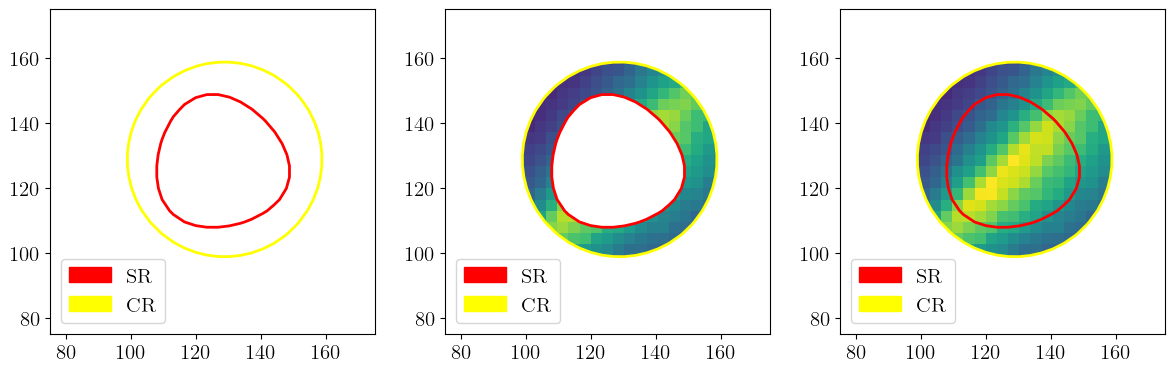

In [4]:
# density plot
import numpy as np
from matplotlib import patches as mpatches

SR_color = "#4ea230"
CR_color = "#0070c0"

# use latex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 15
plt.rcParams["figure.titlesize"] = 15

m_H = 125
sigma_C = 1
K_s = 1
K_c = 1
sigma_C = 1.03
K_s = 0.16
K_c = 30

SR_fn = lambda dm_0, dm_1: np.sqrt((1 - m_H / dm_0)**2 + (1 - m_H / dm_1)**2) 
CR_fn = lambda dm_0, dm_1: np.sqrt((dm_0 - sigma_C * m_H)**2 + (dm_1 - sigma_C * m_H)**2) 

m_diff = np.stack(
    [df_bg4b["m01"] - df_bg4b["m23"],
    df_bg4b["m02"] - df_bg4b["m13"], 
    df_bg4b["m03"] - df_bg4b["m12"],
    ], axis=1)
m_diff = np.abs(m_diff)
m_diff_argmin = np.argmin(m_diff, axis=1)
m1 = np.where(m_diff_argmin == 0, df_bg4b["m01"],
                np.where(m_diff_argmin == 1, df_bg4b["m02"], df_bg4b["m03"]))
m2 = np.where(m_diff_argmin == 0, df_bg4b["m23"],
                np.where(m_diff_argmin == 1, df_bg4b["m13"], df_bg4b["m12"]))

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
# fig.suptitle("Background $\mathrm{4b}$")
# fig.supxlabel("$m_1 (\mathrm{GeV})$")
# fig.supylabel("$m_2 (\mathrm{GeV})$")

# heatmap
m_min = 75
m_max = 175
xedges = np.linspace(m_min, m_max, 30)
yedges = np.linspace(m_min, m_max, 30)
H, xedges, yedges = np.histogram2d(m1, m2, bins=(xedges, yedges))
H = H.T
X, Y = np.meshgrid(xedges, yedges)


for ax in axs:
    ax.pcolormesh(X, Y, H, shading="auto", cmap="viridis")
    ax.set_xlim(m_min, m_max)
    ax.set_ylim(m_min, m_max)
    ax.set_aspect("equal")
    ax.contour(X, Y, SR_fn(X, Y), levels=[K_s], colors=SR_color, linewidths=2)
    ax.contour(X, Y, CR_fn(X, Y), levels=[K_c], colors=CR_color, linewidths=2)


axs[0].contourf(X, Y, SR_fn(X, Y), levels=[0, K_s], colors="white")
axs[0].contourf(X, Y, CR_fn(X, Y), levels=[0, np.inf], colors="white")
axs[1].contourf(X, Y, SR_fn(X, Y), levels=[0, K_s], colors="white")
axs[1].contourf(X, Y, CR_fn(X, Y), levels=[K_c, np.inf], colors="white")
# axs[2].contourf(X, Y, SR_fn(X, Y), levels=[0, K_s], colors="white")
axs[2].contourf(X, Y, CR_fn(X, Y), levels=[K_c, np.inf], colors="white")

for ax in axs:
    SR_patch = mpatches.Patch(color=SR_color, label="SR")
    CR_patch = mpatches.Patch(color=CR_color, label="CR")
    ax.legend(handles=[SR_patch, CR_patch], loc="lower left")

plt.tight_layout()
plt.savefig("./figures/SR_bg4b_interpolation.png", dpi=300)
plt.show()
plt.close()


$\mathrm{HH} \rightarrow 4b$ in SR: 0.8047705470572984


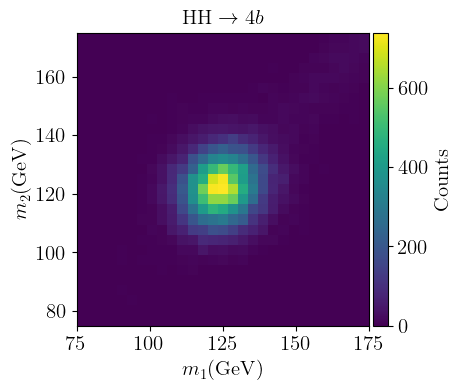

In [9]:
# density plot
from matplotlib import patches as mpatches

# use latex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 15

m_H = 125
sigma_C = 1
K_s = 1
K_c = 1
sigma_C = 1.03
K_s = 0.16
K_c = 30

SR_fn = lambda dm_0, dm_1: np.sqrt((1 - m_H / dm_0)**2 + (1 - m_H / dm_1)**2) 
CR_fn = lambda dm_0, dm_1: np.sqrt((dm_0 - sigma_C * m_H)**2 + (dm_1 - sigma_C * m_H)**2) 

fig, axs = plt.subplots(1, 1, figsize=(5, 4))
axs.set_xlabel("$m_1 (\mathrm{GeV})$")
axs.set_ylabel("$m_2 (\mathrm{GeV})$")
for ax, (name, df) in zip([axs], [(r"$\mathrm{HH} \rightarrow 4b$", df_hh4b)]):
    m_diff = np.stack(
        [df["m01"] - df["m23"],
        df["m02"] - df["m13"], 
        df["m03"] - df["m12"],
        ], axis=1)
    m_diff = np.abs(m_diff)
    m_diff_argmin = np.argmin(m_diff, axis=1)
    m1 = np.where(m_diff_argmin == 0, df["m01"],
                    np.where(m_diff_argmin == 1, df["m02"], df["m03"]))
    m2 = np.where(m_diff_argmin == 0, df["m23"],
                    np.where(m_diff_argmin == 1, df["m13"], df["m12"]))
    
    print(f"{name} in SR: {np.mean(SR_fn(m1, m2) < K_s)}")
    
    # heatmap
    m_min = 75
    m_max = 175
    xedges = np.linspace(m_min, m_max, 30)
    yedges = np.linspace(m_min, m_max, 30)
    H, xedges, yedges = np.histogram2d(m1, m2, bins=(xedges, yedges))
    H = H.T
    X, Y = np.meshgrid(xedges, yedges)
    ax.pcolormesh(X, Y, H, shading="auto", cmap="viridis")

    # add colorbar
    cbar = plt.colorbar(ax.pcolormesh(X, Y, H, shading="auto", cmap="viridis"), fraction=0.047, pad=0.01)
    cbar.set_label("Counts")

    ax.set_xlim(m_min, m_max)
    ax.set_ylim(m_min, m_max)
    
    # ax.contour(X, Y, SR_fn(X, Y), levels=[K_s], colors="red", linewidths=2)
    # ax.contour(X, Y, CR_fn(X, Y), levels=[K_c], colors="yellow", linewidths=2)
    
    # add manual legend
    
    ax.set_aspect("equal")
    ax.set_title(name)

plt.tight_layout()
plt.savefig("./figures/m1m2_heatmap_signal.png", dpi=300)
plt.show()
plt.close()


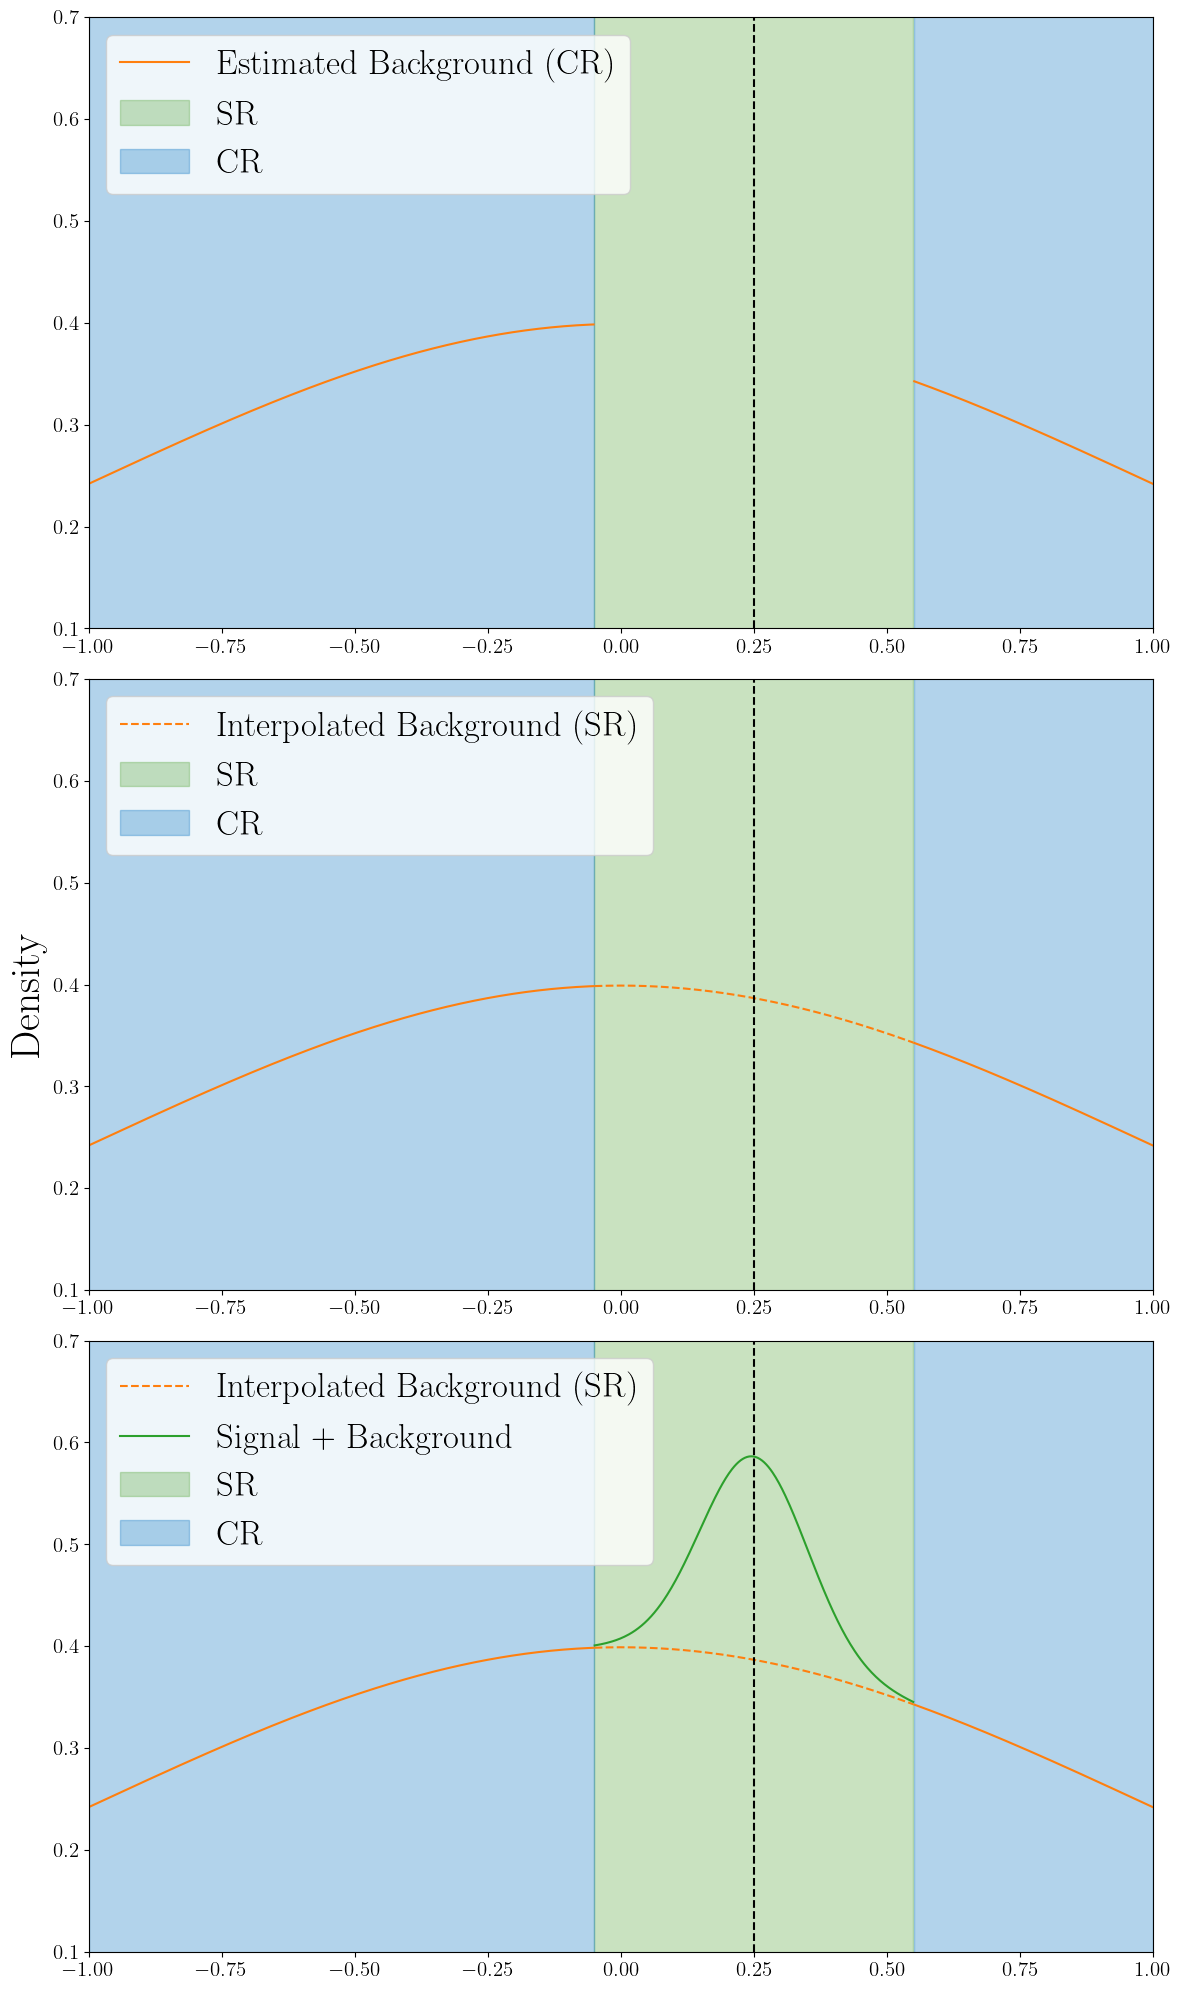

In [61]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

x_range = np.linspace(-1, 1, 1000)
pdf_1 = stats.norm.pdf(x_range, loc=0, scale=1)

signal_center = 0.25
signal_width = 0.1
pdf_2 = 0.05 * stats.norm.pdf(x_range, loc=signal_center, scale=signal_width)

sr_x1 = signal_center - 3 * signal_width
sr_x2 = signal_center + 3 * signal_width

in_SR = (x_range >= sr_x1) & (x_range <= sr_x2)
in_CR_left = (x_range < sr_x1)
in_CR_right = (x_range > sr_x2)
in_CR = in_CR_left | in_CR_right

fig, axs = plt.subplots(3, 1, figsize=(12, 20))
# fig.supxlabel("$x$", fontsize=30)
fig.supylabel("Density", fontsize=30)


axs[0].plot(x_range[in_CR_left], pdf_1[in_CR_left], color=plt.cm.tab10.colors[1], label="Estimated Background (CR)")
axs[0].plot(x_range[in_CR_right], pdf_1[in_CR_right], color=plt.cm.tab10.colors[1])
# axs[0].plot(x_range[in_SR], pdf_1[in_SR], linestyle="--", label="Estimated Background (CR)")
# axs[0].plot(x_range[in_SR], pdf_1[in_SR] + pdf_2[in_SR], color=plt.cm.tab10.colors[2], label="Signal + Background")

axs[1].plot(x_range[in_CR_left], pdf_1[in_CR_left], color=plt.cm.tab10.colors[1])
axs[1].plot(x_range[in_CR_right], pdf_1[in_CR_right], color=plt.cm.tab10.colors[1])
axs[1].plot(x_range[in_SR], pdf_1[in_SR], linestyle="--", label="Interpolated Background (SR)", color=plt.cm.tab10.colors[1])

axs[2].plot(x_range[in_CR_left], pdf_1[in_CR_left], color=plt.cm.tab10.colors[1])
axs[2].plot(x_range[in_CR_right], pdf_1[in_CR_right], color=plt.cm.tab10.colors[1])
axs[2].plot(x_range[in_SR], pdf_1[in_SR], linestyle="--", label="Interpolated Background (SR)", color=plt.cm.tab10.colors[1])
axs[2].plot(x_range[in_SR], pdf_1[in_SR] + pdf_2[in_SR], color=plt.cm.tab10.colors[2], label="Signal + Background")



CR_color = "#0070c0"
SR_color = "#4ea230"

for ax in axs:
    ax.axvline(signal_center, color="black", linestyle="--")
    ax.fill_betweenx(y=[0, 1], x1=sr_x1, x2=sr_x2, color=SR_color, alpha=0.3, label="SR")
    ax.fill_between(x_range, y1=0, y2=1, where=in_CR, color=CR_color, alpha=0.3, label="CR")
    ax.set_ylim(0.1, 0.7)
    ax.set_xlim(-1, 1)
    ax.legend(loc="upper left", fontsize=25)
    
    


plt.tight_layout()
plt.savefig("./figures/bg_estimation_toy_example.png", dpi=300)
plt.show()
plt.close()

3b-jet events:  275508
4b-jet events:  382108
HH4b-jet events:  28656


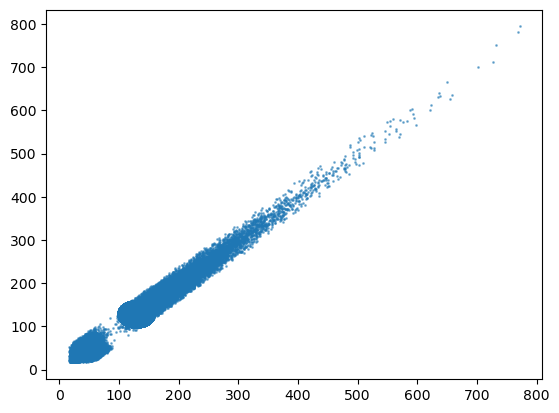

In [4]:
print(df_3b["SR"].mean())
print(df_3b["SB"].mean())
print(df_3b["CR"].mean())

0.5488878725844621
0.0
0.45111212741553786


In [3]:
import pathlib
import pandas as pd

events_directory = pathlib.Path("../events/MG3")


df_3b = pd.read_hdf(events_directory / "dataframes" / "threeTag_picoAOD.h5")
df_bg4b = pd.read_hdf(events_directory / "dataframes" / "fourTag_10x_picoAOD.h5")
df_hh4b = pd.read_hdf(events_directory / "dataframes" / "HH4b_picoAOD.h5")

In [4]:
print(df_3b["weight"].sum())
print(df_3b["weight"].sum() / len(df_3b))

print(df_bg4b["weight"].sum())
print(df_bg4b["weight"].sum() / len(df_bg4b))

print(df_hh4b["weight"].sum())
print(df_hh4b["weight"].sum() / len(df_hh4b))

2299881.5
1.1424559498445932
2297896.5
1.043426051680523
33009.656
1.069797000583355


In [8]:
from dataset import generate_mother_dataset
from events_data import EventsData

n_3b = 1_400_000
ratio_4b = 0.5
signal_ratio = 0.02
signal_filename = "HH4b_picoAOD.h5"
seed = 42

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

for seed in range(0, 100):
    scd, df = generate_mother_dataset(
        n_3b=n_3b, 
        ratio_4b=ratio_4b,
        signal_ratio=signal_ratio,
        signal_filename=signal_filename,
        seed=seed)
    
    event = EventsData.from_dataframe(df, features=features)
    print(event.total_weight_signal)

31987.734
31987.387
31986.695
31992.738
31989.832
31984.98
31982.447
31988.812
31989.164
31992.648


KeyboardInterrupt: 